# Etapa 2 — Análise Exploratória de Dados

Entrada: os CSVs que a Etapa 1 gravou em `../data/raw/`.
Saída: uma tabela horária limpa em `../data/processed/dataset.csv`, mais os
gráficos e as conclusões que sustentam o que você vai afirmar.

As seções abaixo são um roteiro, não uma receita. Responda as perguntas de
cada uma com código e, no fim, em texto. Acrescente seções se quiser.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

DIR_RAW = Path("..") / "data" / "raw"
DIR_PROC = Path("..") / "data" / "processed"
DIR_PROC.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 120)

## 1. Carregar os CSVs

Leia os quatro arquivos de `../data/raw/`.

- Quantas linhas tem cada um? O número faz sentido para o período coletado?
- Os tipos vieram certos, ou datas e números chegaram como texto?
- Há colunas vazias, ou linhas duplicadas?

In [ ]:
mares = pd.read_csv(DIR_RAW / "mares_2025.csv")
mares_prev = pd.read_csv(DIR_RAW / "mares_previsao.csv")
ondas = pd.read_csv(DIR_RAW / "ondas.csv")
vento = pd.read_csv(DIR_RAW / "vento.csv")

tabelas = {"mares_2025": mares, "mares_previsao": mares_prev, "ondas": ondas, "vento": vento}
for nome, df in tabelas.items():
    print(f"{nome}: {df.shape[0]} linhas x {df.shape[1]} colunas | "
          f"nulos: {int(df.isna().sum().sum())} | duplicadas: {int(df.duplicated().sum())}")
    print(df.dtypes.to_string(), "\n")

mares_2025: 1410 linhas x 6 colunas | nulos: 0 | duplicadas: 0
data               str
hora               str
altura_m       float64
tipo               str
coeficiente      int64
fase_lua         int64 

mares_previsao: 120 linhas x 6 colunas | nulos: 0 | duplicadas: 0
data               str
hora               str
altura_m       float64
tipo               str
coeficiente      int64
fase_lua         int64 

ondas: 168 linhas x 4 colunas | nulos: 0 | duplicadas: 0
data                 str
hora                 str
altura_onda_m    float64
direcao              str 

vento: 168 linhas x 4 colunas | nulos: 0 | duplicadas: 0
data             str
hora             str
vento_kmh    float64
direcao          str 



In [ ]:
print("Marés 2025: dias distintos =", mares["data"].nunique(), "| eventos por dia:",
      mares.groupby("data").size().value_counts().to_dict())
print("Marés (mês corrente): dias =", mares_prev["data"].nunique(),
      "de", mares_prev["data"].min(), "a", mares_prev["data"].max())
for nome, df in [("Ondas", ondas), ("Vento", vento)]:
    print(f"{nome}: {df['data'].nunique()} dias x {df.groupby('data').size().unique()} horas | "
          f"{df['data'].min()} a {df['data'].max()}")

Marés 2025: dias distintos = 365 | eventos por dia: {4: 315, 3: 50}
Marés (mês corrente): dias = 31 de 2026-10-01 a 2026-10-31
Ondas: 7 dias x [24] horas | 2026-10-08 a 2026-10-14
Vento: 7 dias x [24] horas | 2026-10-08 a 2026-10-14


Os números fazem sentido: 365 dias em 2025 (315 com 4 marés e 50 com 3), 31 dias de outubro na tábua do mês e 7 dias × 24 horas em ondas e vento. Não há nulos nem duplicatas. Só `data` e `hora` vieram como texto.

## 2. Limpeza

Deixe cada tabela num estado em que dá para confiar.

- Datas e horas: viram `datetime`? Vale montar uma coluna única de data + hora?
- Decimais: o site usa vírgula. Isso já foi resolvido na Etapa 1 ou sobrou aqui?
- O que fazer com nulos: descartar a linha, preencher, ou manter e documentar?
- Duplicatas: existem? De onde vieram?

In [ ]:
def com_datetime(df):
    df = df.copy()
    df["datetime"] = pd.to_datetime(df["data"] + " " + df["hora"], format="%Y-%m-%d %H:%M")
    return df.drop(columns=["data", "hora"])

mares = com_datetime(mares).drop_duplicates()
mares_prev = com_datetime(mares_prev).drop_duplicates()
ondas = com_datetime(ondas).drop_duplicates()
vento = com_datetime(vento).drop_duplicates()

ROSA = {d: i * 22.5 for i, d in enumerate(
    ["N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE",
     "S", "SSO", "SO", "OSO", "O", "ONO", "NO", "NNO"])}
for df in (ondas, vento):
    desconhecidas = set(df["direcao"]) - set(ROSA)
    print("direções fora da rosa dos ventos:", desconhecidas or "nenhuma")
    df["direcao_graus"] = df["direcao"].map(ROSA)

print("Direções de onda:", sorted(ondas["direcao"].unique(), key=ROSA.get))
print("Direções de vento:", sorted(vento["direcao"].unique(), key=ROSA.get))

direções fora da rosa dos ventos: nenhuma
direções fora da rosa dos ventos: nenhuma
Direções de onda: ['E', 'ESE']
Direções de vento: ['E', 'ESE', 'SE', 'SSE']


In [ ]:
print("Nulos restantes:", sum(int(d.isna().sum().sum()) for d in (mares, mares_prev, ondas, vento)))
print("Horas duplicadas em ondas/vento:", ondas["datetime"].duplicated().sum(), vento["datetime"].duplicated().sum())
display(mares[["altura_m", "coeficiente"]].describe().round(2))
display(ondas["altura_onda_m"].describe().round(2).to_frame().join(vento["vento_kmh"].describe().round(2)))

Nulos restantes: 0
Horas duplicadas em ondas/vento: 0 0


,altura_m,coeficiente
count,1410.00,1410.00
mean,1.37,67.62
std,0.86,19.55
min,0.00,27.00
25%,0.50,52.00
50%,1.35,68.00
75%,2.20,82.00
max,2.80,114.00


,altura_onda_m,vento_kmh
count,168.00,168.00
mean,1.13,22.32
std,0.13,2.77
min,0.90,13.00
25%,1.00,21.00
50%,1.10,23.00
75%,1.20,24.00
max,1.40,28.00


Data e hora viraram uma coluna só e as direções viraram ângulos. A onda vem arredondada em 0,1 m e varia pouco (0,9 a 1,4 m).

## 3. Explorar cada tabela separadamente

Antes de juntar, entenda cada fonte.

**Marés** — como a altura se distribui entre marés altas e baixas? O
coeficiente varia ao longo do ano com algum padrão? Ele tem relação com a
fase da lua?

**Ondas** — qual a faixa de altura na janela coletada? Há padrão por hora do
dia, ou a variação é só por dia?

**Vento** — quais horas são mais calmas? A direção predominante muda ao longo
do dia? (Vento da terra para o mar e vento do mar para a terra fazem coisas
opostas com a onda.)

Um gráfico por pergunta. Escreva o que você leu nele.

### Marés

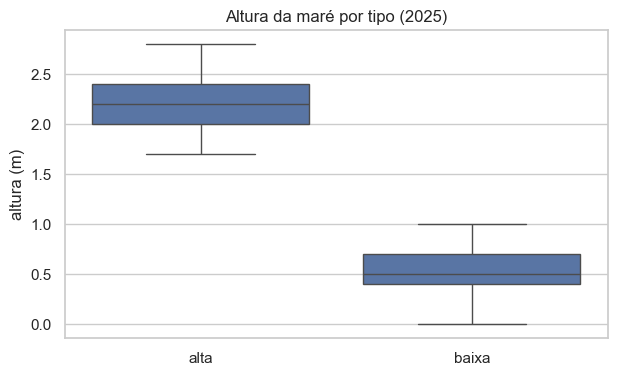

,count,mean,std,min,25%,50%,75%,max
tipo,,,,,,,,
alta,705.0,2.20,0.24,1.7,2.0,2.2,2.4,2.8
baixa,705.0,0.54,0.22,0.0,0.4,0.5,0.7,1.0


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=mares, x="tipo", y="altura_m", ax=ax)
ax.set(title="Altura da maré por tipo (2025)", xlabel="", ylabel="altura (m)")
plt.show()
display(mares.groupby("tipo")["altura_m"].describe().round(2))

As marés altas ficam perto de 2,2 m e as baixas perto de 0,5 m, quase sem sobreposição.

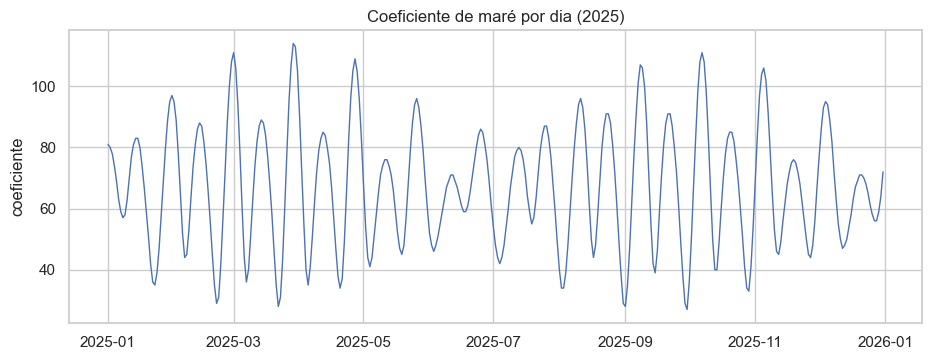

In [ ]:
diario = mares.assign(dia=mares["datetime"].dt.normalize()).groupby("dia")[["coeficiente", "fase_lua"]].first()
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(diario.index, diario["coeficiente"], lw=1)
ax.set(title="Coeficiente de maré por dia (2025)", ylabel="coeficiente")
plt.show()

O coeficiente sobe e desce a cada duas semanas, entre 27 e 114. Os maiores picos aparecem em março-abril e setembro-outubro.

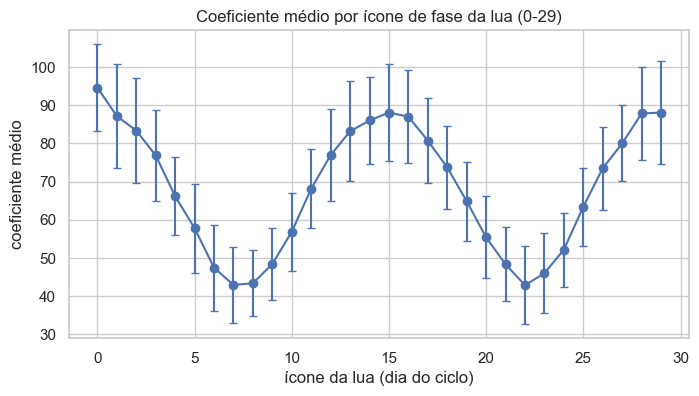

Ícone com maior coeficiente médio: 0 | menor: 22


In [ ]:
por_lua = diario.groupby("fase_lua")["coeficiente"].agg(["mean", "std", "count"])
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(por_lua.index, por_lua["mean"], yerr=por_lua["std"], marker="o", capsize=3)
ax.set(title="Coeficiente médio por ícone de fase da lua (0-29)", xlabel="ícone da lua (dia do ciclo)", ylabel="coeficiente médio")
plt.show()
print("Ícone com maior coeficiente médio:", por_lua["mean"].idxmax(), "| menor:", por_lua["mean"].idxmin())

O coeficiente é alto na lua nova e na cheia (ícones 0 e 15) e baixo nos quartos (ícones 7 e 22). Ou seja, ele acompanha a lua.

### Ondas

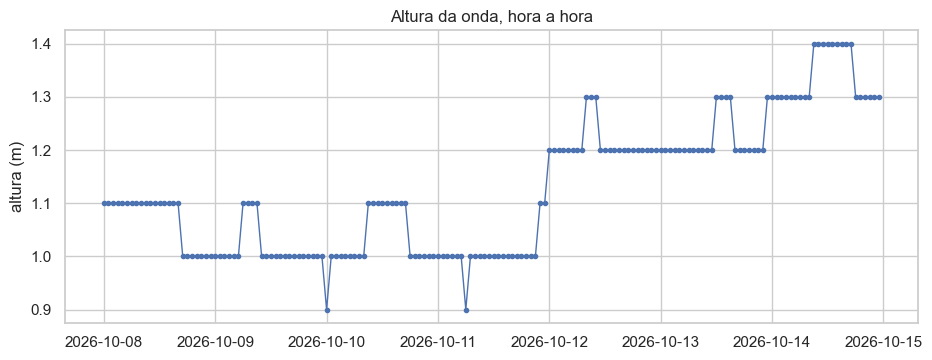

In [ ]:
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(ondas["datetime"], ondas["altura_onda_m"], marker=".", lw=1)
ax.set(title="Altura da onda, hora a hora", ylabel="altura (m)")
plt.show()

A onda fica entre 0,9 e 1,4 m. Ela é menor de 08 a 11/10 (cerca de 1,0 m) e maior de 12 a 14/10 (1,2 a 1,4 m).

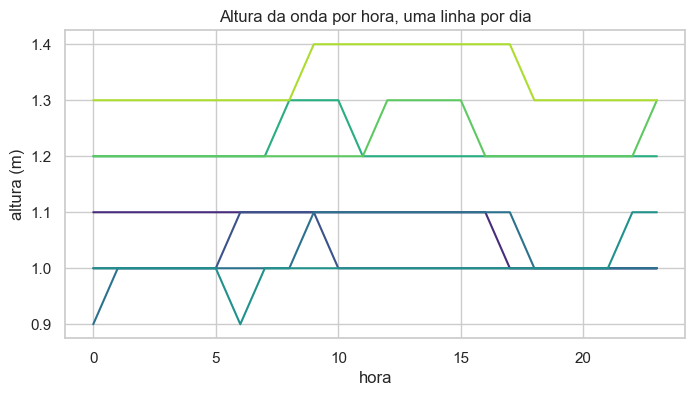

Variação média entre horas do mesmo dia (amplitude): 0.13 m
Variação entre médias diárias (amplitude): 0.33 m


In [ ]:
ondas["hora"] = ondas["datetime"].dt.hour
vento["hora"] = vento["datetime"].dt.hour
ondas["dia"] = ondas["datetime"].dt.date
fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=ondas, x="hora", y="altura_onda_m", hue="dia", palette="viridis", legend=False, ax=ax)
ax.set(title="Altura da onda por hora, uma linha por dia", ylabel="altura (m)")
plt.show()
print("Variação média entre horas do mesmo dia (amplitude): %.2f m" % ondas.groupby("dia")["altura_onda_m"].apply(lambda s: s.max() - s.min()).mean())
medias = ondas.groupby("dia")["altura_onda_m"].mean()
print("Variação entre médias diárias (amplitude): %.2f m" % (medias.max() - medias.min()))

A onda muda mais de um dia para o outro (0,33 m) do que ao longo de um mesmo dia (0,13 m). Para a altura da onda, o que importa é o dia, não a hora.

### Vento

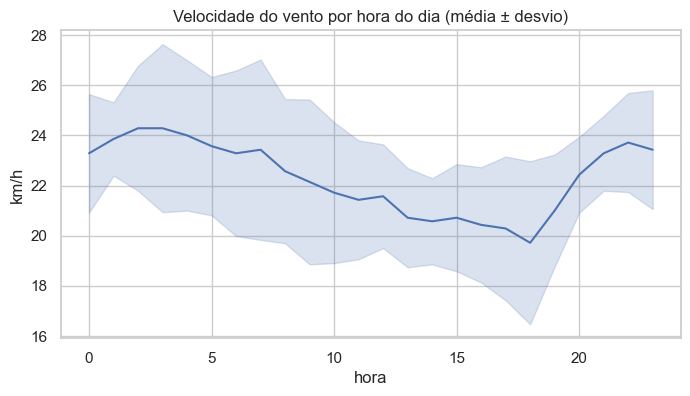

,km/h médio
hora,
18,19.7
17,20.3
16,20.4
14,20.6
15,20.7


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=vento, x="hora", y="vento_kmh", errorbar="sd", ax=ax)
ax.set(title="Velocidade do vento por hora do dia (média ± desvio)", ylabel="km/h")
plt.show()
display(vento.groupby("hora")["vento_kmh"].mean().round(1).sort_values().head(5).to_frame("km/h médio"))

O vento é mais fraco no fim da tarde (cerca de 20 km/h) e mais forte de madrugada (cerca de 24 km/h).

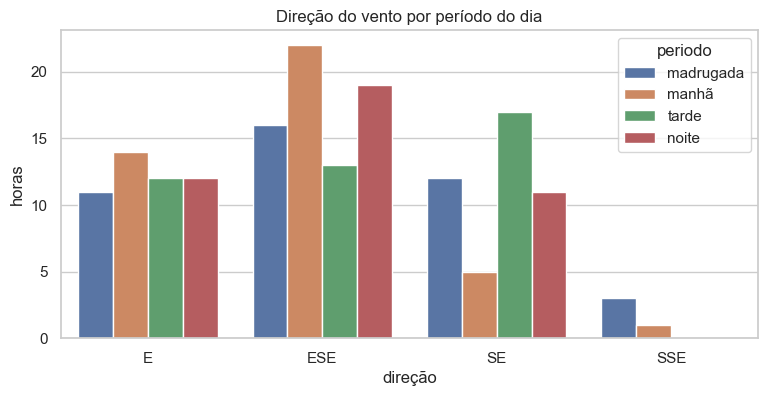

In [ ]:
bins, nomes = [-1, 5, 11, 17, 23], ["madrugada", "manhã", "tarde", "noite"]
vento["periodo"] = pd.cut(vento["hora"], bins=bins, labels=nomes)
ordem = sorted(vento["direcao"].unique(), key=ROSA.get)
fig, ax = plt.subplots(figsize=(9, 4))
sns.countplot(data=vento, x="direcao", hue="periodo", order=ordem, ax=ax)
ax.set(title="Direção do vento por período do dia", xlabel="direção", ylabel="horas")
plt.show()

O vento vem sempre de E a SSE, nunca do oeste. Como a costa de João Pessoa olha para o leste, é vento do mar para a terra.

## 4. Juntar as tabelas

Esta é a parte difícil, e ela tem mais de uma resposta certa.

As granularidades não batem: onda e vento são leituras horárias; maré são ~4
eventos por dia (os instantes de máxima e mínima). Para ter uma linha por hora
com as três informações você precisa decidir:

- Como levar a maré para a grade horária? Interpolar entre eventos? Repetir o
  último valor? Guardar apenas se a maré está subindo ou descendo? O que cada
  escolha assume sobre a curva real da maré — e onde essa suposição erra?
- Qual o tipo de junção? A previsão de onda e a de vento cobrem exatamente as
  mesmas horas? Se não, você mantém as horas incompletas ou corta?
- Que variáveis derivadas de tempo ajudam a responder a pergunta do projeto
  (dia da semana, período do dia, ...)?

Justifique as escolhas em markdown. Elas são a base das duas próximas etapas.

### Decisões de junção

- **Grade horária:** junto ondas e vento com `inner join`. As duas fontes cobrem as mesmas 168 horas, então nenhuma hora é perdida.
- **Maré:** interpolo entre os eventos da tábua com uma curva em cosseno, que lembra o formato real da maré. Também guardo se a maré está subindo. A suposição erra quando a subida e a descida duram tempos diferentes.
- **Direção:** converto para ângulo e uso seno e cosseno, porque 350° e 10° são direções vizinhas.
- **Tempo:** crio `hora`, `dia_semana` e `periodo`.

In [ ]:
ondas_h = ondas.rename(columns={"direcao": "direcao_onda", "direcao_graus": "onda_graus"})[
    ["datetime", "altura_onda_m", "direcao_onda", "onda_graus"]]
vento_h = vento.rename(columns={"direcao": "direcao_vento", "direcao_graus": "vento_graus"})[
    ["datetime", "vento_kmh", "direcao_vento", "vento_graus"]]

grade = ondas_h.merge(vento_h, on="datetime", how="inner", validate="one_to_one")
print("horas em ondas:", len(ondas_h), "| em vento:", len(vento_h), "| na junção:", len(grade))

horas em ondas: 168 | em vento: 168 | na junção: 168


In [ ]:
eventos = mares_prev.sort_values("datetime").reset_index(drop=True)
t_ev = eventos["datetime"].to_numpy()
h_ev = eventos["altura_m"].to_numpy()

def mare_na_hora(instantes):
    t = instantes.to_numpy()
    j = np.searchsorted(t_ev, t, side="right")
    assert (j > 0).all() and (j < len(t_ev)).all(), "a grade sai do intervalo coberto pela tábua"
    i = j - 1
    f = (t - t_ev[i]) / (t_ev[j] - t_ev[i])
    altura = h_ev[i] + (h_ev[j] - h_ev[i]) * (1 - np.cos(np.pi * f)) / 2
    return altura, h_ev[j] > h_ev[i]

grade["mare_m"], grade["mare_subindo"] = mare_na_hora(grade["datetime"])
grade["mare_subindo"] = grade["mare_subindo"].astype(int)

por_dia = (mares_prev.assign(dia=mares_prev["datetime"].dt.normalize())
           .groupby("dia")[["coeficiente", "fase_lua"]].first())
dia = grade["datetime"].dt.normalize()
grade["coeficiente"] = dia.map(por_dia["coeficiente"])
grade["fase_lua"] = dia.map(por_dia["fase_lua"])
print("nulos no coeficiente/lua:", int(grade[["coeficiente", "fase_lua"]].isna().sum().sum()))

nulos no coeficiente/lua: 0


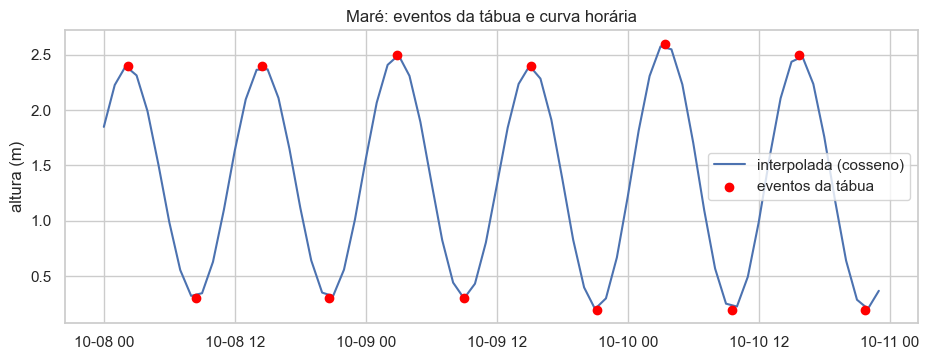

In [ ]:
ini, fim = grade["datetime"].min(), grade["datetime"].min() + pd.Timedelta(days=3)
g = grade[grade["datetime"] < fim]
e = eventos[(eventos["datetime"] >= ini) & (eventos["datetime"] < fim)]
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(g["datetime"], g["mare_m"], label="interpolada (cosseno)")
ax.scatter(e["datetime"], e["altura_m"], c="red", zorder=3, label="eventos da tábua")
ax.set(title="Maré: eventos da tábua e curva horária", ylabel="altura (m)")
ax.legend()
plt.show()

In [ ]:
grade["hora"] = grade["datetime"].dt.hour
grade["dia_semana"] = grade["datetime"].dt.dayofweek
grade["periodo"] = pd.cut(grade["hora"], bins=[-1, 5, 11, 17, 23], labels=["madrugada", "manhã", "tarde", "noite"])

for pref in ("onda", "vento"):
    rad = np.deg2rad(grade[f"{pref}_graus"])
    grade[f"{pref}_sen"], grade[f"{pref}_cos"] = np.sin(rad), np.cos(rad)

dataset = grade.sort_values("datetime").reset_index(drop=True)
print(dataset.shape, "| nulos:", int(dataset.isna().sum().sum()))
dataset.head()

(168, 18) | nulos: 0


,datetime,altura_onda_m,direcao_onda,onda_graus,vento_kmh,direcao_vento,vento_graus,mare_m,mare_subindo,coeficiente,fase_lua,hora,dia_semana,periodo,onda_sen,onda_cos,vento_sen,vento_cos
0,2026-10-08 00:00:00,1.1,E,90.0,21.0,SE,135.0,1.847960,1,91,27,0,3,madrugada,1.0,6.123234e-17,0.707107,-0.707107
1,2026-10-08 01:00:00,1.1,E,90.0,22.0,SE,135.0,2.225559,1,91,27,1,3,madrugada,1.0,6.123234e-17,0.707107,-0.707107
2,2026-10-08 02:00:00,1.1,E,90.0,20.0,SE,135.0,2.395688,1,91,27,2,3,madrugada,1.0,6.123234e-17,0.707107,-0.707107
3,2026-10-08 03:00:00,1.1,E,90.0,18.0,SSE,157.5,2.312306,0,91,27,3,3,madrugada,1.0,6.123234e-17,0.382683,-0.923880
4,2026-10-08 04:00:00,1.1,E,90.0,18.0,SSE,157.5,1.989782,0,91,27,4,3,madrugada,1.0,6.123234e-17,0.382683,-0.923880


A junção manteve as 168 horas, sem nulos. A curva da maré passa pelos eventos reais da tábua.

## 5. Visualizações voltadas à pergunta

Agora com a tabela junta: quando as condições coincidem?

- As horas de onda maior são as mesmas de vento mais fraco, ou elas se
  desencontram?
- Existe relação visível entre altura da maré e altura da onda?
- Quais dias e horas da janela se destacam?

Prefira poucos gráficos legíveis a muitos gráficos.

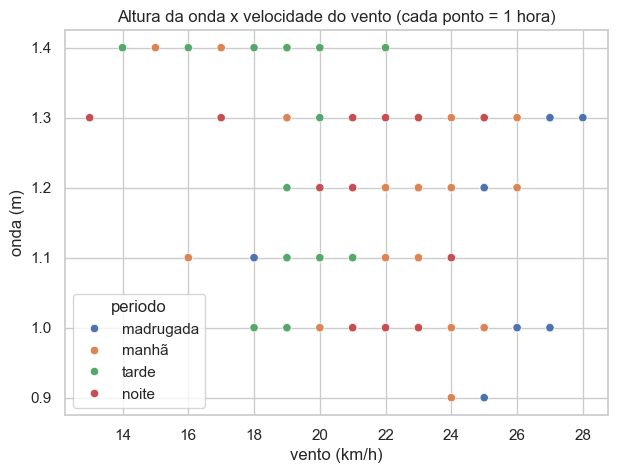

correlação onda x vento: -0.29


In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=dataset, x="vento_kmh", y="altura_onda_m", hue="periodo", ax=ax)
ax.set(title="Altura da onda x velocidade do vento (cada ponto = 1 hora)", xlabel="vento (km/h)", ylabel="onda (m)")
plt.show()
print("correlação onda x vento: %.2f" % dataset["altura_onda_m"].corr(dataset["vento_kmh"]))

A correlação é -0,29: onda maior tende a vir com vento um pouco mais fraco, mas a relação é fraca.

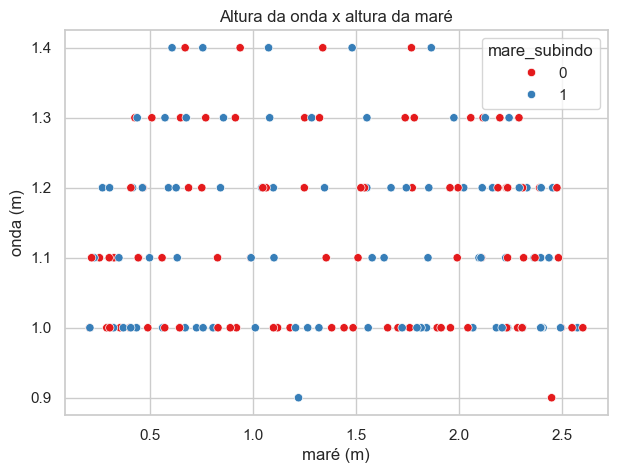

correlação onda x maré: -0.04


In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=dataset, x="mare_m", y="altura_onda_m", hue="mare_subindo", palette="Set1", ax=ax)
ax.set(title="Altura da onda x altura da maré", xlabel="maré (m)", ylabel="onda (m)")
plt.show()
print("correlação onda x maré: %.2f" % dataset["altura_onda_m"].corr(dataset["mare_m"]))

A correlação é -0,04: não há relação visível entre a maré e a altura da onda.

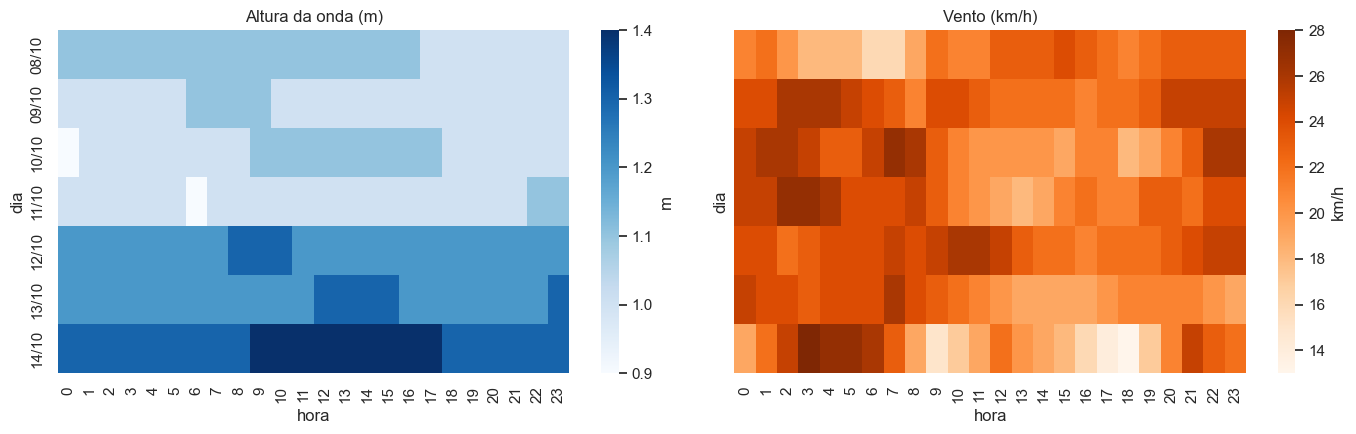

In [ ]:
dataset["dia"] = dataset["datetime"].dt.strftime("%d/%m")
fig, axs = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
sns.heatmap(dataset.pivot(index="dia", columns="hora", values="altura_onda_m"), cmap="Blues", annot=False, ax=axs[0], cbar_kws={"label": "m"})
axs[0].set_title("Altura da onda (m)")
sns.heatmap(dataset.pivot(index="dia", columns="hora", values="vento_kmh"), cmap="Oranges", ax=axs[1], cbar_kws={"label": "km/h"})
axs[1].set_title("Vento (km/h)")
plt.tight_layout()
plt.show()

O dia 14/10 se destaca: onda de 1,4 m e vento mais fraco (13 a 18 km/h) entre 9h e 17h. Os dias 09 a 11/10 têm as ondas mais baixas.

## 6. Salvar o dataset processado

Grave o resultado em `../data/processed/dataset.csv`. A Etapa 3 lê esse
arquivo — se as colunas mudarem depois, o notebook de ML muda também.

In [ ]:
dataset = dataset.drop(columns=["dia"])
dataset.to_csv(DIR_PROC / "dataset.csv", index=False)
print(f"dataset.csv: {len(dataset)} linhas x {dataset.shape[1]} colunas")
print(list(dataset.columns))

dataset.csv: 168 linhas x 18 colunas
['datetime', 'altura_onda_m', 'direcao_onda', 'onda_graus', 'vento_kmh', 'direcao_vento', 'vento_graus', 'mare_m', 'mare_subindo', 'coeficiente', 'fase_lua', 'hora', 'dia_semana', 'periodo', 'onda_sen', 'onda_cos', 'vento_sen', 'vento_cos']


## 7. Conclusões

Em texto, sem código:

1. O que os dados mostram sobre as condições da janela coletada?
2. Que decisão de limpeza ou de junção você tomou que mais influencia o
   resultado, e por quê?
3. O que esses dados **não** permitem afirmar?

1. **O que os dados mostram.** A onda cresce de cerca de 1,0 m para 1,4 m ao longo da semana. O melhor momento é a tarde de 14/10, com onda maior e vento mais fraco. O vento é sempre do mar para a terra. A maré segue a lua, mas não tem relação com a altura da onda.
2. **Decisão mais importante.** Interpolar a maré em cosseno, porque define as features de maré da Etapa 3.
3. **O que os dados não permitem afirmar.** A melhor época do ano, porque só temos uma semana de ondas e vento. Também não temos o período da onda, e a previsão tem erro. Além disso, as linhas são muito parecidas entre si, então há menos informação do que as 168 linhas sugerem.